# 01 Initial Experiment: Mock Pharma Trial Response Model

This notebook is the first experiment notebook for the mock pharma MLflow production project.

The objective is to build a simple but production-minded baseline model that predicts whether a participant in a mock clinical trial is likely to respond to treatment.

This notebook covers:

1. Creating/loading a synthetic clinical-trial dataset
2. Exploratory data analysis
3. Feature and target definition
4. Train/test split
5. Baseline modelling
6. MLflow experiment tracking
7. Model artifact saving
8. Loading the saved model for inference

This is demo/portfolio code only. It does not use real patient data and must not be used for medical decision-making.

## 1. Setup

The notebook assumes it is being run from the project root, or that the project `src` directory is available on the Python path.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()


if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

PROJECT_ROOT

PosixPath('/home/raither/projects/MOCKPHARMA')

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()


PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"


In [3]:
import json
import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from pharma_trial_ml.config import (
    DATA_PATH,
    MODEL_DIR,
    MODEL_PATH,
    METADATA_PATH,
    EXPERIMENT_NAME,
    MLFLOW_TRACKING_URI,
)
from pharma_trial_ml.data import generate_mock_trial_data
from pharma_trial_ml.features import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET,
    build_preprocessor,
)

## 2. Create or load mock clinical-trial data

The dataset is synthetic. It contains plausible clinical-trial style features such as age, BMI, baseline biomarker value, dose, adherence, prior treatments, sex and trial arm.

The target is `responder`, where:

- `1` = participant responded to treatment
- `0` = participant did not respond

In [4]:
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    df = generate_mock_trial_data(n_rows=2500, random_state=42)
    df.to_csv(DATA_PATH, index=False)

df.head()

,age,bmi,baseline_biomarker,dose_mg,adherence_pct,prior_treatments,sex,trial_arm,responder
0,58.7,30.8,55.36,50,98.3,2,M,placebo,0
1,42.5,29.2,54.61,25,52.7,2,M,active,0
2,64.0,33.0,47.46,25,100.0,1,M,placebo,0
3,66.3,30.4,67.71,10,93.6,2,M,active,0
4,31.6,34.1,64.22,25,100.0,1,M,active,1


## 3. Basic data checks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 2500 non-null   float64
 1   bmi                 2500 non-null   float64
 2   baseline_biomarker  2500 non-null   float64
 3   dose_mg             2500 non-null   int64  
 4   adherence_pct       2500 non-null   float64
 5   prior_treatments    2500 non-null   int64  
 6   sex                 2500 non-null   object 
 7   trial_arm           2500 non-null   object 
 8   responder           2500 non-null   int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 175.9+ KB


In [6]:
df.describe(include="all")

,age,bmi,baseline_biomarker,dose_mg,adherence_pct,prior_treatments,sex,trial_arm,responder
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500,2500,2500.00000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,F,active,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1368,1376,NaN
mean,54.450440,28.034760,60.415888,40.190000,84.958040,1.335600,NaN,NaN,0.19080
std,12.003172,4.929863,18.136261,20.607857,10.655266,1.139953,NaN,NaN,0.39301
min,18.000000,16.000000,5.000000,10.000000,48.600000,0.000000,NaN,NaN,0.00000
25%,46.475000,24.600000,48.400000,25.000000,77.675000,0.000000,NaN,NaN,0.00000
50%,54.900000,28.000000,59.960000,50.000000,85.500000,1.000000,NaN,NaN,0.00000
75%,62.400000,31.200000,72.742500,50.000000,93.600000,2.000000,NaN,NaN,0.00000


In [7]:
df[TARGET].value_counts(normalize=True).rename("proportion")

responder
0    0.8092
1    0.1908
Name: proportion, dtype: float64

## 4. Simple exploratory analysis

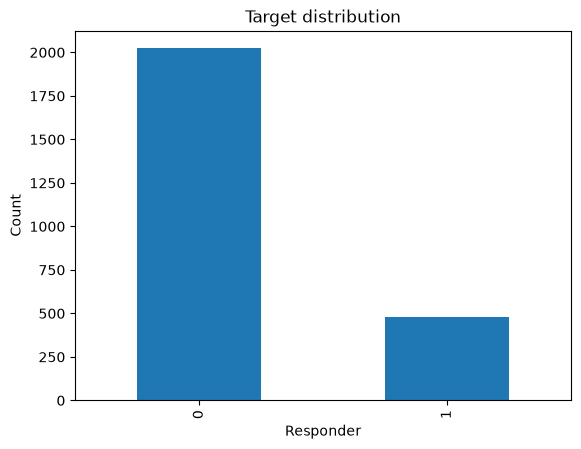

In [8]:
ax = df[TARGET].value_counts().sort_index().plot(kind="bar")
ax.set_title("Target distribution")
ax.set_xlabel("Responder")
ax.set_ylabel("Count")
plt.show()

In [9]:
numeric_summary = df[NUMERIC_FEATURES].agg(["mean", "std", "min", "max"]).T
numeric_summary

,mean,std,min,max
age,54.450440,12.003172,18.0,85.00
bmi,28.034760,4.929863,16.0,45.00
baseline_biomarker,60.415888,18.136261,5.0,119.29
dose_mg,40.190000,20.607857,10.0,75.00
adherence_pct,84.958040,10.655266,48.6,100.00
prior_treatments,1.335600,1.139953,0.0,6.00


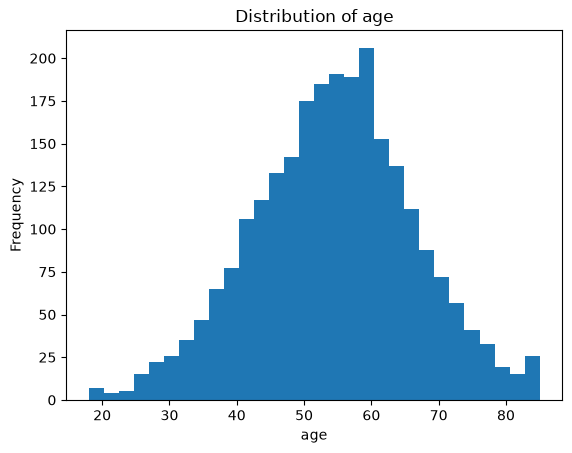

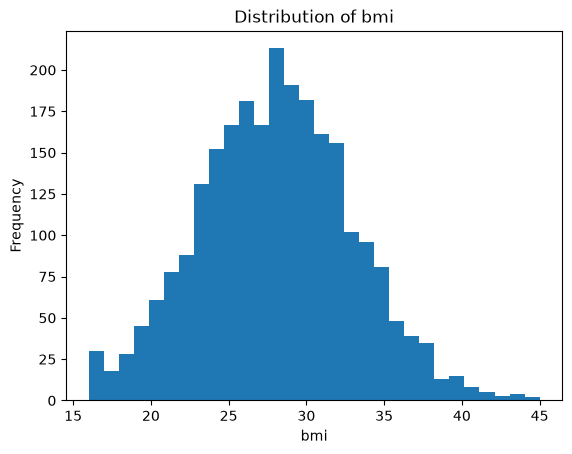

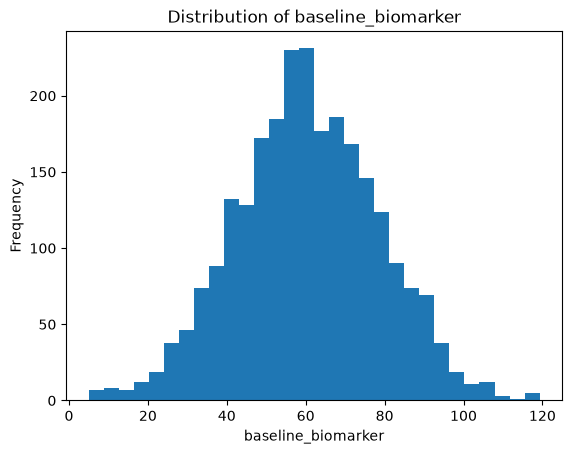

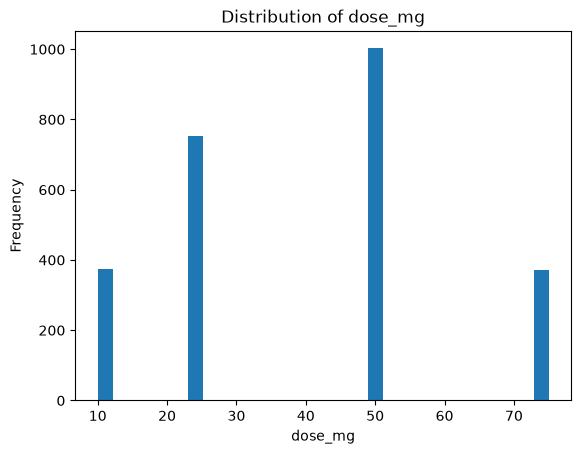

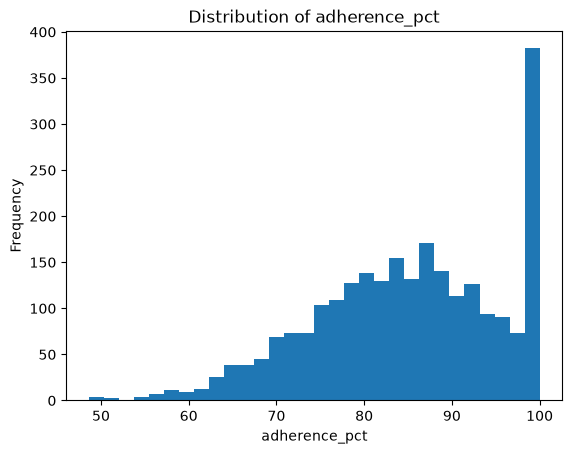

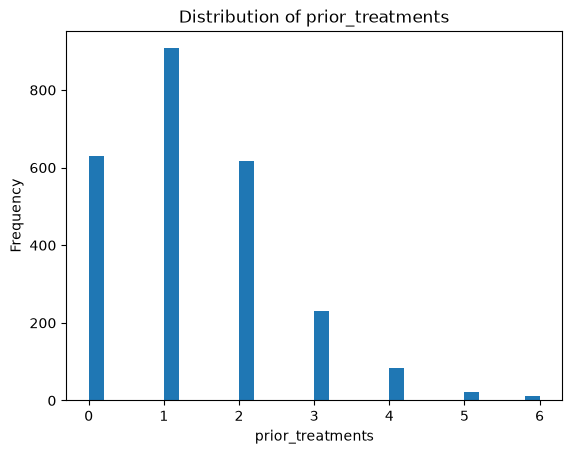

In [10]:
for col in NUMERIC_FEATURES:
    ax = df[col].plot(kind="hist", bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    plt.show()

In [11]:
response_by_arm = df.groupby("trial_arm")[TARGET].mean().sort_values(ascending=False)
response_by_arm

trial_arm
active     0.287064
placebo    0.072954
Name: responder, dtype: float64

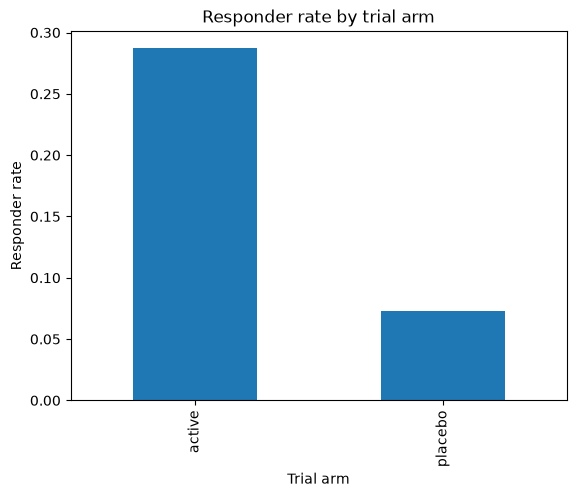

In [12]:
ax = response_by_arm.plot(kind="bar")
ax.set_title("Responder rate by trial arm")
ax.set_xlabel("Trial arm")
ax.set_ylabel("Responder rate")
plt.show()

## 5. Define features and target

In [13]:
feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[feature_columns]
y = df[TARGET]

X.head()

,age,bmi,baseline_biomarker,dose_mg,adherence_pct,prior_treatments,sex,trial_arm
0,58.7,30.8,55.36,50,98.3,2,M,placebo
1,42.5,29.2,54.61,25,52.7,2,M,active
2,64.0,33.0,47.46,25,100.0,1,M,placebo
3,66.3,30.4,67.71,10,93.6,2,M,active
4,31.6,34.1,64.22,25,100.0,1,M,active


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((1875, 8), (625, 8))

## 6. Build candidate models

For the first experiment, use two simple model families:

1. Logistic regression as a transparent baseline
2. Random forest as a non-linear tree-based baseline

A later notebook can replace this with GridSearchCV or Optuna.

In [15]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }


candidates = [
    (
        "logistic_regression",
        Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=1000,
                        C=1.0,
                        class_weight="balanced",
                    ),
                ),
            ]
        ),
        {"C": 1.0, "class_weight": "balanced"},
    ),
    (
        "random_forest",
        Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=200,
                        max_depth=6,
                        min_samples_leaf=8,
                        random_state=42,
                        class_weight="balanced",
                    ),
                ),
            ]
        ),
        {
            "n_estimators": 200,
            "max_depth": 6,
            "min_samples_leaf": 8,
            "class_weight": "balanced",
        },
    ),
]

## 7. Track experiments with MLflow

This section logs:

- model type
- hyperparameters
- evaluation metrics
- trained model artifact
- confusion matrix
- ROC curve

The best model is selected using F1 score.

In [16]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

best_model = None
best_model_name = None
best_metrics = None
best_run_id = None
best_f1 = -1

for model_name, model, params in candidates:
    with mlflow.start_run(run_name=f"initial_{model_name}") as run:
        model.fit(X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test)

        mlflow.log_param("model_name", model_name)
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        # Confusion matrix artifact
        fig, ax = plt.subplots()
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
        ax.set_title(f"Confusion matrix: {model_name}")
        confusion_path = PROJECT_ROOT / "models" / f"{model_name}_confusion_matrix.png"
        fig.savefig(confusion_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(confusion_path), artifact_path="plots")

        # ROC curve artifact
        fig, ax = plt.subplots()
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
        ax.set_title(f"ROC curve: {model_name}")
        roc_path = PROJECT_ROOT / "models" / f"{model_name}_roc_curve.png"
        fig.savefig(roc_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(str(roc_path), artifact_path="plots")

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            input_example=X_test.head(3),
        )

        print(model_name, metrics)

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_model = model
            best_model_name = model_name
            best_metrics = metrics
            best_run_id = run.info.run_id

best_model_name, best_metrics, best_run_id

/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

logistic_regression {'accuracy': 0.7312, 'precision': 0.3881278538812785, 'recall': 0.7142857142857143, 'f1': 0.5029585798816568, 'roc_auc': np.float64(0.8029029793735676)}


/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/raither/projects/MOCKPHARMA/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:435: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

random_forest {'accuracy': 0.7568, 'precision': 0.4153846153846154, 'recall': 0.680672268907563, 'f1': 0.5159235668789809, 'roc_auc': np.float64(0.7888364832098848)}


('random_forest',
 {'accuracy': 0.7568,
  'precision': 0.4153846153846154,
  'recall': 0.680672268907563,
  'f1': 0.5159235668789809,
  'roc_auc': np.float64(0.7888364832098848)},
 'b7ec31afd6834d3d878a25dabd325af9')

## 8. Save the first production candidate locally

The API in this repo loads from `models/trial_response_model.joblib`.

For a real production system, this would usually be loaded from the MLflow Model Registry instead.

In [17]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

metadata = {
    "model_name": best_model_name,
    "model_path": str(MODEL_PATH),
    "best_run_id": best_run_id,
    "best_metrics": best_metrics,
    "features": feature_columns,
    "target": TARGET,
}

METADATA_PATH.write_text(json.dumps(metadata, indent=2))

metadata

{'model_name': 'random_forest',
 'model_path': '/home/raither/projects/MOCKPHARMA/models/trial_response_model.joblib',
 'best_run_id': 'b7ec31afd6834d3d878a25dabd325af9',
 'best_metrics': {'accuracy': 0.7568,
  'precision': 0.4153846153846154,
  'recall': 0.680672268907563,
  'f1': 0.5159235668789809,
  'roc_auc': np.float64(0.7888364832098848)},
 'features': ['age',
  'bmi',
  'baseline_biomarker',
  'dose_mg',
  'adherence_pct',
  'prior_treatments',
  'sex',
  'trial_arm'],
 'target': 'responder'}

## 9. Load the saved model and run a test prediction

In [18]:
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame(
    [
        {
            "age": 54,
            "bmi": 29.5,
            "baseline_biomarker": 68.2,
            "dose_mg": 50,
            "adherence_pct": 92,
            "prior_treatments": 1,
            "sex": "F",
            "trial_arm": "active",
        }
    ]
)

probability = loaded_model.predict_proba(sample)[0, 1]
prediction = int(probability >= 0.5)

{
    "prediction": prediction,
    "responder_probability": round(float(probability), 4),
}

{'prediction': 1, 'responder_probability': 0.7112}